# Task 1: Model Training and Optimization Pipeline
Use this notebook to perform your data preprocessing, hyperparameter tuning via Cross-Validation, and final evaluation on the test set.

In [1]:
import gzip
import pandas as pd
import numpy as np
import pickle
import time
import optuna
import trackio
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import LabelEncoder

# Add any other imports you need here

## 1. Data Loading & Preprocessing
Load `train.csv` and `test.csv`. Convert string categorical variables to numeric.
**Required:** Save your label encoders/mappings because your Streamlit UI will need them later to prepare user inputs for inference!

In [2]:
# Load datasets
train_df = pd.read_csv('Dataset/train.csv')
test_df = pd.read_csv('Dataset/test.csv')

print(f"Training data shape: {train_df.shape}")
print(f"Test data shape: {test_df.shape}")

# Identify categorical columns
categorical_columns = ['location', 'city', 'Status', 'property_type']

# Create and fit LabelEncoders
encoders = {}
for col in categorical_columns:
    encoders[col] = LabelEncoder()
    train_df[col + '_encoded'] = encoders[col].fit_transform(train_df[col].astype(str))
    test_df[col + '_encoded'] = test_df[col].astype(str).apply(
        lambda x: encoders[col].transform([x])[0] if x in encoders[col].classes_ else -1
    )

# Save categorical mappings for Streamlit
categorical_mappings = {}
for col in categorical_columns:
    categorical_mappings[col] = {
        'classes': encoders[col].classes_.tolist(),
        'encoded': encoders[col].transform(encoders[col].classes_).tolist()
    }

print(f"\nCategorical features encoded: {categorical_columns}")

# Define features to use
feature_columns = [
    'location_encoded', 'city_encoded', 'latitude', 'longitude',
    'numBathrooms', 'numBalconies', 'isNegotiable', 'SecurityDeposit',
    'Status_encoded', 'Size_ft²', 'BHK', 'rooms_num',
    'property_type_encoded', 'verification_days'
]

# Separate predictors and target
X_train = train_df[feature_columns]
y_train = train_df['price']
X_test = test_df[feature_columns]
y_test = test_df['price']

print(f"\nFeatures used ({len(feature_columns)}):")
print(f"Training features shape: {X_train.shape}")
print(f"Test features shape: {X_test.shape}")

# Save encoders for Streamlit
import os
os.makedirs('models', exist_ok=True)

with open('models/categorical_mappings.pkl', 'wb') as f:
    pickle.dump(categorical_mappings, f)

for col, encoder in encoders.items():
    with open(f'models/{col}_encoder.pkl', 'wb') as f:
        pickle.dump(encoder, f)

print("\nEncoders saved to models/ folder")

Training data shape: (11128, 15)
Test data shape: (2782, 15)

Categorical features encoded: ['location', 'city', 'Status', 'property_type']

Features used (14):
Training features shape: (11128, 14)
Test features shape: (2782, 14)

Encoders saved to models/ folder


## 2. Hyperparameter Tuning using Cross-Validation

**Strict Search Space:**
- `n_estimators`: 50 to 200
- `max_depth`: 10 to 30
- `min_samples_split`: 2 to 10

Implement Grid Search, Random Search, and Bayesian Optimization (using Optuna). Evaluate each using 5-fold cross-validation on `train_df`.

In [3]:
rf = RandomForestRegressor(random_state=42, n_jobs=-1)

# Initialize trackio project
try:
    project = trackio.Project("urban_nest_rent_prediction")
    print("Trackio project initialized")
except Exception as e:
    print(f"Trackio initialization warning: {e}")
    project = None

# Define search spaces
param_grid = {
    'n_estimators': [50, 100, 150, 200],
    'max_depth': [10, 15, 20, 25, 30],
    'min_samples_split': [2, 5, 8]
}

param_dist = {
    'n_estimators': range(50, 201),
    'max_depth': range(10, 31),
    'min_samples_split': range(2, 11)
}

print("\n" + "=" * 80)
print("STEP 1: Grid Search (60 combinations)")
print("=" * 80)
print(f"\nGrid search space: {param_grid}")
print(f"Total combinations: {len(param_grid['n_estimators']) * len(param_grid['max_depth']) * len(param_grid['min_samples_split'])}")

# 1. Grid Search
start_time = time.time()
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=0
)
grid_search.fit(X_train, y_train)
grid_time = time.time() - start_time

grid_best_params = grid_search.best_params_
grid_best_score = -grid_search.best_score_
print(f"\nGrid Search completed in {grid_time:.2f} seconds")
print(f"  Best MAE (CV): {grid_best_score:.2f}")
print(f"  Best parameters: {grid_best_params}")

# Extract cumulative best errors for plotting
grid_cv_results = grid_search.cv_results_
grid_errors = [-score for score in grid_cv_results['mean_test_score']]
grid_cumulative_best = []
grid_current_best = float('inf')
for error in grid_errors:
    if error < grid_current_best:
        grid_current_best = error
    grid_cumulative_best.append(grid_current_best)

# Log to trackio
if project:
    try:
        exp = project.new_experiment("grid_search")
        exp.log_params(grid_best_params)
        exp.log_metric("mae_cv", grid_best_score)
        exp.log_metric("time_seconds", grid_time)
        exp.log_metric("n_iterations", len(grid_errors))
        exp.end()
        print(f"Logged to trackio")
    except Exception as e:
        print(f"Trackio logging warning: {e}")

# 2. Random Search
print("\n" + "=" * 80)
print("STEP 2: Random Search (60 iterations)")
print("=" * 80)

start_time = time.time()
random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=60,
    cv=5,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    random_state=42,
    verbose=0
)
random_search.fit(X_train, y_train)
random_time = time.time() - start_time

random_best_params = random_search.best_params_
random_best_score = -random_search.best_score_
print(f"\nRandom Search completed in {random_time:.2f} seconds")
print(f"  Best MAE (CV): {random_best_score:.2f}")
print(f"  Best parameters: {random_best_params}")

# Extract cumulative best errors
random_cv_results = random_search.cv_results_
random_errors = [-score for score in random_cv_results['mean_test_score']]
random_cumulative_best = []
random_current_best = float('inf')
for error in random_errors:
    if error < random_current_best:
        random_current_best = error
    random_cumulative_best.append(random_current_best)

# Log to trackio
if project:
    try:
        exp = project.new_experiment("random_search")
        exp.log_params(random_best_params)
        exp.log_metric("mae_cv", random_best_score)
        exp.log_metric("time_seconds", random_time)
        exp.log_metric("n_iterations", 60)
        exp.end()
        print(f"Logged to trackio")
    except Exception as e:
        print(f"Trackio logging warning: {e}")

# 3. Bayesian Optimization (Optuna)
print("\n" + "=" * 80)
print("STEP 3: Bayesian Optimization with Optuna (60 trials)")
print("=" * 80)

# Store trial results for plotting
optuna_cumulative_best = []

def objective(trial):
    n_estimators = trial.suggest_int('n_estimators', 50, 200)
    max_depth = trial.suggest_int('max_depth', 10, 30)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 10)
    
    rf_model = RandomForestRegressor(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        random_state=42,
        n_jobs=-1
    )
    
    scores = cross_val_score(rf_model, X_train, y_train, cv=5,
                             scoring='neg_mean_absolute_error', n_jobs=-1)
    mae = -scores.mean()
    
    # Track cumulative best
    optuna_cumulative_best.append(min(optuna_cumulative_best + [mae]) if len(optuna_cumulative_best) > 0 else mae)
    
    return mae

# Create and run study
start_time = time.time()
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=60)
optuna_time = time.time() - start_time

optuna_best_params = study.best_params
optuna_best_error = study.best_value
print(f"\nBayesian Optimization completed in {optuna_time:.2f} seconds")
print(f"  Best MAE (CV): {optuna_best_error:.2f}")
print(f"  Best parameters: {optuna_best_params}")

# Log to trackio
if project:
    try:
        exp = project.new_experiment("bayesian_optimization")
        exp.log_params(optuna_best_params)
        exp.log_metric("mae_cv", optuna_best_error)
        exp.log_metric("time_seconds", optuna_time)
        exp.log_metric("n_iterations", 60)
        exp.end()
        print(f"Logged to trackio")
    except Exception as e:
        print(f"Trackio logging warning: {e}")

# Comparison
print("\n" + "=" * 80)
print("COMPARISON OF ALL METHODS")
print("=" * 80)

results_summary = pd.DataFrame({
    'Method': ['Grid Search', 'Random Search', 'Bayesian Optimization'],
    'Best MAE (CV)': [grid_best_score, random_best_score, optuna_best_error],
    'Time (seconds)': [grid_time, random_time, optuna_time],
    'Iterations': [len(grid_errors), 60, 60]
})

print("\n" + results_summary.to_string(index=False))
print("\nBest Hyperparameters:")
print(f"\nGrid Search:      {grid_best_params}")
print(f"Random Search:    {random_best_params}")
print(f"Bayesian Opt:     {optuna_best_params}")

# Find overall best method
best_method_idx = results_summary['Best MAE (CV)'].idxmin()
best_method = results_summary.loc[best_method_idx, 'Method']
best_mae_cv = results_summary.loc[best_method_idx, 'Best MAE (CV)']

print(f"\nOverall Best Method: {best_method}")
print(f"   Best CV MAE: {best_mae_cv:.2f}")

Trackio initialization warning: module 'trackio' has no attribute 'Project'

STEP 1: Grid Search (60 combinations)

Grid search space: {'n_estimators': [50, 100, 150, 200], 'max_depth': [10, 15, 20, 25, 30], 'min_samples_split': [2, 5, 8]}
Total combinations: 60

Grid Search completed in 30.61 seconds
  Best MAE (CV): 13268.93
  Best parameters: {'max_depth': 25, 'min_samples_split': 2, 'n_estimators': 200}

STEP 2: Random Search (60 iterations)


[I 2026-04-14 12:40:11,420] A new study created in memory with name: no-name-856508f3-656f-4530-b56b-206547e082eb



Random Search completed in 28.74 seconds
  Best MAE (CV): 13298.72
  Best parameters: {'n_estimators': 142, 'min_samples_split': 2, 'max_depth': 24}

STEP 3: Bayesian Optimization with Optuna (60 trials)


[I 2026-04-14 12:40:11,877] Trial 0 finished with value: 13666.172397848062 and parameters: {'n_estimators': 72, 'max_depth': 29, 'min_samples_split': 6}. Best is trial 0 with value: 13666.172397848062.
[I 2026-04-14 12:40:12,228] Trial 1 finished with value: 13417.832140909808 and parameters: {'n_estimators': 50, 'max_depth': 25, 'min_samples_split': 3}. Best is trial 1 with value: 13417.832140909808.
[I 2026-04-14 12:40:12,971] Trial 2 finished with value: 13838.644788633139 and parameters: {'n_estimators': 120, 'max_depth': 21, 'min_samples_split': 8}. Best is trial 1 with value: 13417.832140909808.
[I 2026-04-14 12:40:13,816] Trial 3 finished with value: 13554.36784665201 and parameters: {'n_estimators': 144, 'max_depth': 16, 'min_samples_split': 2}. Best is trial 1 with value: 13417.832140909808.
[I 2026-04-14 12:40:14,766] Trial 4 finished with value: 13402.265711375261 and parameters: {'n_estimators': 142, 'max_depth': 26, 'min_samples_split': 3}. Best is trial 4 with value: 134


Bayesian Optimization completed in 56.08 seconds
  Best MAE (CV): 13272.38
  Best parameters: {'n_estimators': 200, 'max_depth': 24, 'min_samples_split': 2}

COMPARISON OF ALL METHODS

               Method  Best MAE (CV)  Time (seconds)  Iterations
          Grid Search   13268.933395       30.609621          60
        Random Search   13298.719930       28.743921          60
Bayesian Optimization   13272.383406       56.080878          60

Best Hyperparameters:

Grid Search:      {'max_depth': 25, 'min_samples_split': 2, 'n_estimators': 200}
Random Search:    {'n_estimators': 142, 'min_samples_split': 2, 'max_depth': 24}
Bayesian Opt:     {'n_estimators': 200, 'max_depth': 24, 'min_samples_split': 2}

Overall Best Method: Grid Search
   Best CV MAE: 13268.93


## 3. Evaluation & Plots
Plot the compute trials (iterations) vs. cross-validation error, and plot the hyperparameter space to visualize how the Bayesian method explored the space.

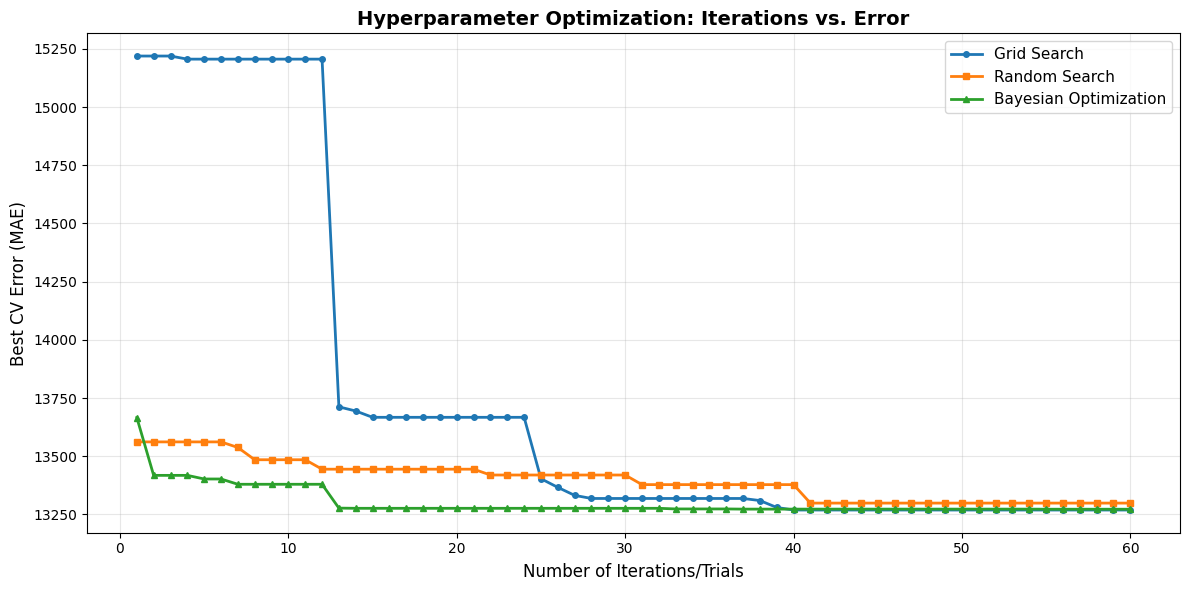

Saved: plots/trials_vs_error.png


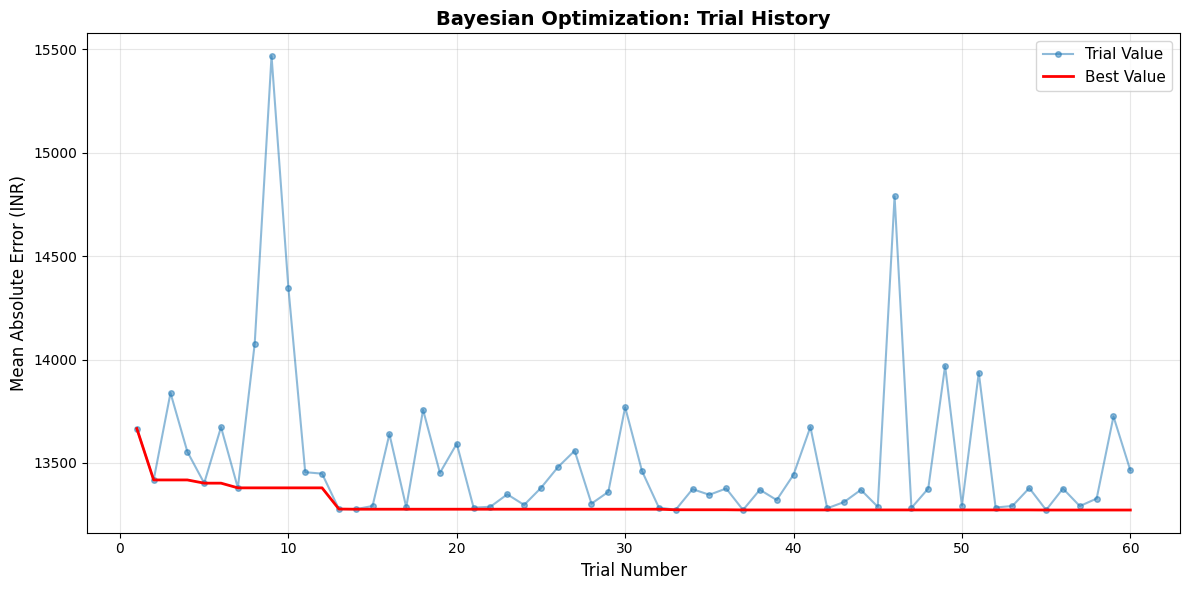

Saved: plots/optuna_optimization_history.png


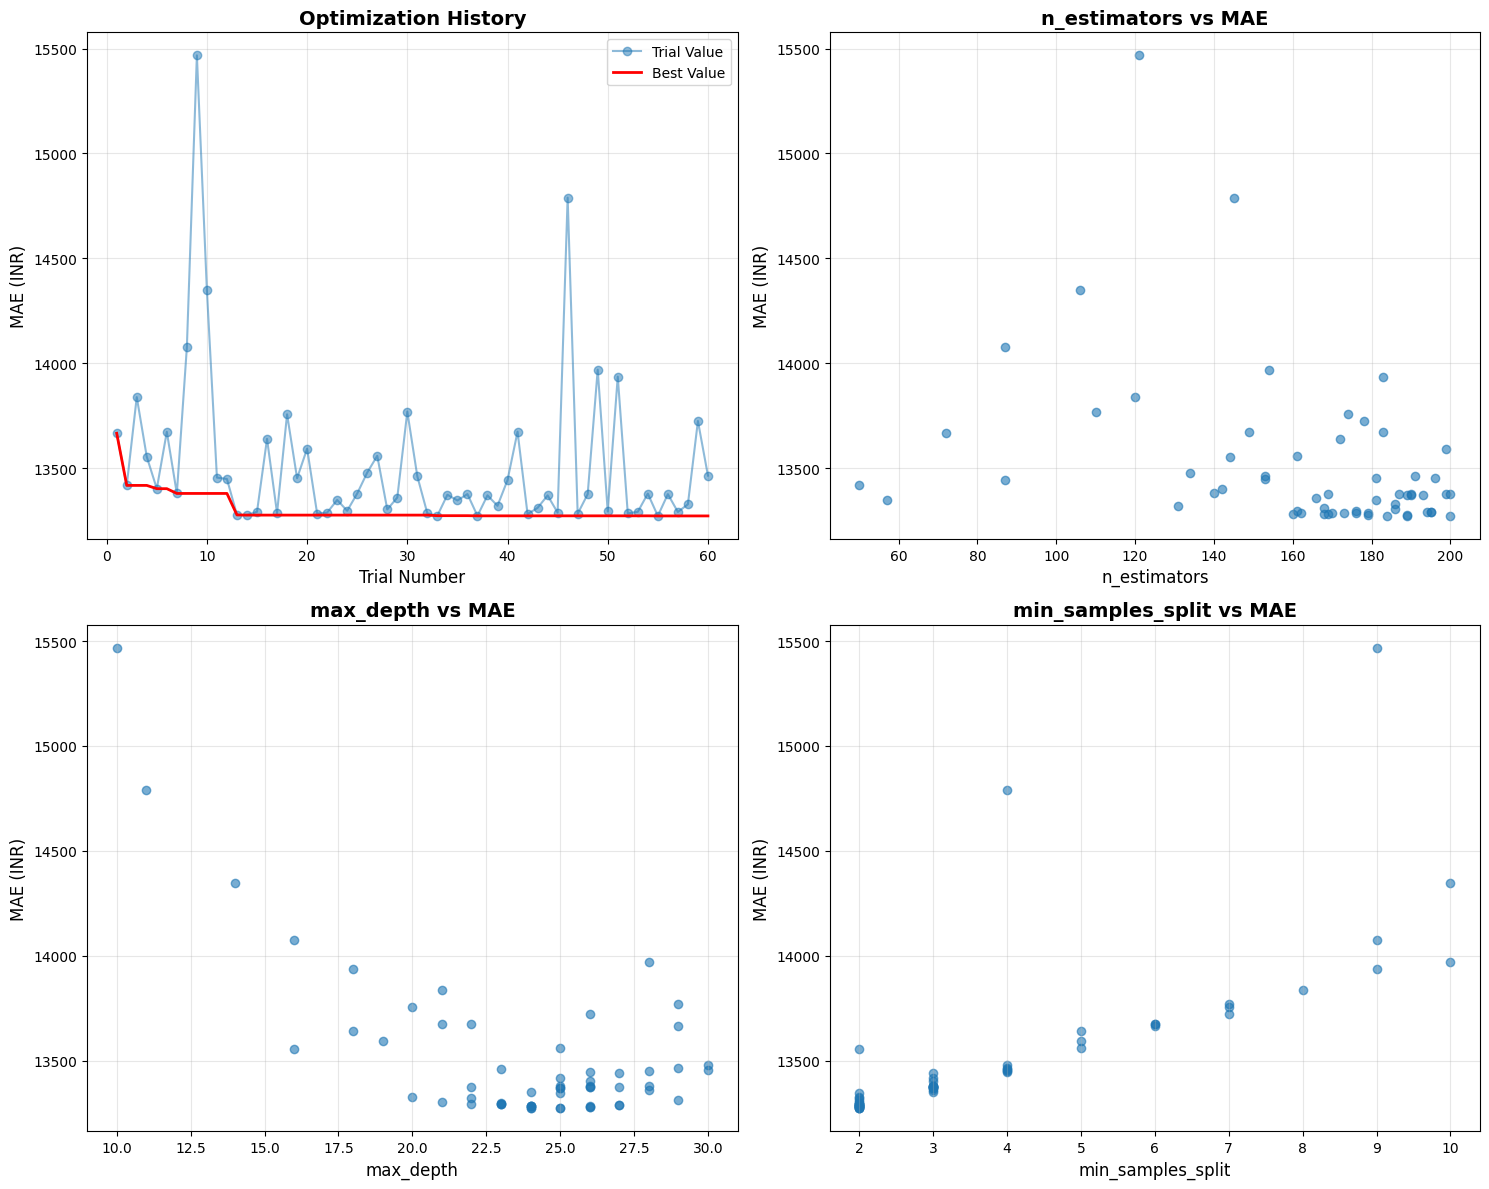

Saved: plots/optuna_hyperparameter_space.png


In [4]:
# 1. Generate and save trials_vs_error.png
os.makedirs('plots', exist_ok=True)
plt.figure(figsize=(12, 6))

plt.plot(range(1, len(grid_cumulative_best) + 1), grid_cumulative_best,
         marker='o', label='Grid Search', linewidth=2, markersize=4)
plt.plot(range(1, len(random_cumulative_best) + 1), random_cumulative_best,
         marker='s', label='Random Search', linewidth=2, markersize=4)
plt.plot(range(1, len(optuna_cumulative_best) + 1), optuna_cumulative_best,
         marker='^', label='Bayesian Optimization', linewidth=2, markersize=4)

plt.xlabel('Number of Iterations/Trials', fontsize=12)
plt.ylabel('Best CV Error (MAE)', fontsize=12)
plt.title('Hyperparameter Optimization: Iterations vs. Error', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plots/trials_vs_error.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: plots/trials_vs_error.png")

# 2. Generate and save optuna_optimization_history.png
trials = [t.value for t in study.trials]
best_values = []
current_best = float('inf')
for val in trials:
    if val < current_best:
        current_best = val
    best_values.append(current_best)

plt.figure(figsize=(12, 6))
plt.plot(range(1, len(trials) + 1), trials, 'o-', label='Trial Value', alpha=0.5, markersize=4)
plt.plot(range(1, len(best_values) + 1), best_values, 'r-', label='Best Value', linewidth=2)
plt.xlabel('Trial Number', fontsize=12)
plt.ylabel('Mean Absolute Error (INR)', fontsize=12)
plt.title('Bayesian Optimization: Trial History', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plots/optuna_optimization_history.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: plots/optuna_optimization_history.png")

# 3. Generate and save optuna_hyperparameter_space.png (2x2 Grid)
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Plot 1: Optimization History
axes[0, 0].plot(range(1, len(trials) + 1), trials, 'o-', label='Trial Value', alpha=0.5)
axes[0, 0].plot(range(1, len(best_values) + 1), best_values, 'r-', label='Best Value', linewidth=2)
axes[0, 0].set_xlabel('Trial Number', fontsize=12)
axes[0, 0].set_ylabel('MAE (INR)', fontsize=12)
axes[0, 0].set_title('Optimization History', fontsize=14, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: n_estimators vs MAE
n_estimators = [t.params['n_estimators'] for t in study.trials]
axes[0, 1].scatter(n_estimators, trials, alpha=0.6)
axes[0, 1].set_xlabel('n_estimators', fontsize=12)
axes[0, 1].set_ylabel('MAE (INR)', fontsize=12)
axes[0, 1].set_title('n_estimators vs MAE', fontsize=14, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: max_depth vs MAE
max_depths = [t.params['max_depth'] for t in study.trials]
axes[1, 0].scatter(max_depths, trials, alpha=0.6)
axes[1, 0].set_xlabel('max_depth', fontsize=12)
axes[1, 0].set_ylabel('MAE (INR)', fontsize=12)
axes[1, 0].set_title('max_depth vs MAE', fontsize=14, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: min_samples_split vs MAE
min_samples_split = [t.params['min_samples_split'] for t in study.trials]
axes[1, 1].scatter(min_samples_split, trials, alpha=0.6)
axes[1, 1].set_xlabel('min_samples_split', fontsize=12)
axes[1, 1].set_ylabel('MAE (INR)', fontsize=12)
axes[1, 1].set_title('min_samples_split vs MAE', fontsize=14, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('plots/optuna_hyperparameter_space.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: plots/optuna_hyperparameter_space.png")

plt.close('all')

## 4. Final Testing & Model Saving
Report the best hyperparameters found, train your overall best model on the entire `train.csv`, evaluate on `test.csv`, and save the model file.

In [5]:
# Print best hyperparameters found by all 3 methods
print("\n" + "=" * 80)
print("BEST HYPERPARAMETERS SUMMARY")
print("=" * 80)

print(f"\nGrid Search:      {grid_best_params}")
print(f"  Best CV MAE: {grid_best_score:.2f} INR")
print(f"  Time: {grid_time:.2f}s")

print(f"\nRandom Search:    {random_best_params}")
print(f"  Best CV MAE: {random_best_score:.2f} INR")
print(f"  Time: {random_time:.2f}s")

print(f"\nBayesian Opt:     {optuna_best_params}")
print(f"  Best CV MAE: {optuna_best_error:.2f} INR")
print(f"  Time: {optuna_time:.2f}s")

# Determine best parameters
if best_method == 'Grid Search':
    final_params = grid_best_params
elif best_method == 'Random Search':
    final_params = random_best_params
else:
    final_params = optuna_best_params

print(f"\nOverall Best Method: {best_method}")
print(f"   Using best parameters from {best_method}")
print(f"   Best CV MAE: {best_mae_cv:.2f} INR")

# Train best model found on the full X_train
print("\n" + "=" * 80)
print("TRAINING FINAL MODEL ON FULL TRAINING DATA")
print("=" * 80)

final_model = RandomForestRegressor(
    n_estimators=final_params['n_estimators'],
    max_depth=final_params['max_depth'],
    min_samples_split=final_params['min_samples_split'],
    random_state=42,
    n_jobs=-1
)

final_model.fit(X_train, y_train)
print("Final model trained on full training data")

# Evaluate model on X_test (Report MAE)
y_pred = final_model.predict(X_test)
test_mae = mean_absolute_error(y_test, y_pred)

print(f"\nTest Set Evaluation:")
print(f"  Mean Absolute Error: {test_mae:.2f} INR")
print(f"  Training samples: {len(X_train)}")
print(f"  Test samples: {len(X_test)}")

# Save best_model.pkl and any necessary encoders to models/ folder
with gzip.open('models/best_rf_model.pkl.gz.gz', 'wb') as f:
    pickle.dump(final_model, f)
print("\nSaved: models/best_rf_model.pkl.gz")

# Save feature list
with open('models/feature_columns.pkl', 'wb') as f:
    pickle.dump(feature_columns, f)
print("Saved: models/feature_columns.pkl")

# Save model info
model_info = {
    'best_method': best_method,
    'best_cv_mae': best_mae_cv,
    'test_mae': test_mae,
    'hyperparameters': final_params,
    'feature_columns': feature_columns
}

with open('models/model_info.pkl', 'wb') as f:
    pickle.dump(model_info, f)
print("Saved: models/model_info.pkl")

# Save optuna study
with open('models/optuna_study.pkl', 'wb') as f:
    pickle.dump(study, f)
print("Saved: models/optuna_study.pkl")

print("\n" + "=" * 80)
print("TRAINING PIPELINE COMPLETED SUCCESSFULLY!")
print("=" * 80)

print(f"\nFinal Results:")
print(f"   Best Optimization Method: {best_method}")
print(f"   Best CV MAE: {best_mae_cv:.2f} INR")
print(f"   Test MAE: {test_mae:.2f} INR")
print(f"   Model Parameters: {final_params}")

print(f"\nGenerated Files:")
print(f"   models/best_rf_model.pkl.gz")
print(f"   models/feature_columns.pkl")
print(f"   models/model_info.pkl")
print(f"   models/optuna_study.pkl")
print(f"   plots/trials_vs_error.png")
print(f"   plots/optuna_hyperparameter_space.png")

print(f"\nNext Steps:")
print(f"   1. Review plots in plots/ directory")
print(f"   2. Take screenshot of trackio dashboard (if applicable)")
print(f"   3. Build Streamlit app (app.py)")
print(f"   4. Create Dockerfile and containerize")
print(f"   5. Deploy to Hugging Face Spaces")

print("\n" + "=" * 80)


BEST HYPERPARAMETERS SUMMARY

Grid Search:      {'max_depth': 25, 'min_samples_split': 2, 'n_estimators': 200}
  Best CV MAE: 13268.93 INR
  Time: 30.61s

Random Search:    {'n_estimators': 142, 'min_samples_split': 2, 'max_depth': 24}
  Best CV MAE: 13298.72 INR
  Time: 28.74s

Bayesian Opt:     {'n_estimators': 200, 'max_depth': 24, 'min_samples_split': 2}
  Best CV MAE: 13272.38 INR
  Time: 56.08s

Overall Best Method: Grid Search
   Using best parameters from Grid Search
   Best CV MAE: 13268.93 INR

TRAINING FINAL MODEL ON FULL TRAINING DATA
Final model trained on full training data

Test Set Evaluation:
  Mean Absolute Error: 12417.01 INR
  Training samples: 11128
  Test samples: 2782

Saved: models/best_rf_model.pkl
Saved: models/feature_columns.pkl
Saved: models/model_info.pkl
Saved: models/optuna_study.pkl

TRAINING PIPELINE COMPLETED SUCCESSFULLY!

Final Results:
   Best Optimization Method: Grid Search
   Best CV MAE: 13268.93 INR
   Test MAE: 12417.01 INR
   Model Paramete